# Lab 1: Understanding Deep Learning Requires Rethinking Generalization

### Introduction

This lab is based on the paper ["Understanding Deep Learning Requires Rethinking Generalization"](https://arxiv.org/abs/1611.03530) by Zhang et al. (ICLR 2017). The paper presents a striking observation: deep neural networks can easily memorize training data with **completely random labels**, achieving near-perfect training accuracy while (unsurprisingly) failing to generalize.

This challenges classical learning theory, which suggests that models with enough capacity to memorize noise should generalize poorly even on real data. Yet in practice, the same overparameterized networks generalize remarkably well on true labels.

### Objectives

1. Observe that overparameterized networks achieve near-perfect training accuracy on MNIST
2. Demonstrate that the same network can memorize **random labels** (zero generalization)
3. Investigate the effect of **model capacity** (hidden size) on training and generalization
4. Test whether **weight decay regularization** can prevent memorization or improve generalization
5. Discuss what these results mean for classical generalization theory

### Setup

We begin by importing the necessary libraries and preparing the MNIST dataset. We use a **10,000-sample subset** of the training data — this keeps training fast while still being sufficient to demonstrate the generalization phenomena from the paper (the model is heavily overparameterized relative to the dataset size). The device is auto-detected to work on CUDA, MPS (Apple Silicon), or CPU.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# Auto-detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

transform = transforms.Compose([transforms.ToTensor()])
batch_size = 256

full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

# Use a 10k subset for training — fast and still heavily overparameterized
subset_size: int = 10_000
train_dataset = Subset(full_train_dataset, list(range(subset_size)))

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

### Explore the Data

Let's visualize a few samples from the MNIST dataset to understand what we're working with.

Batch shape: torch.Size([64, 1, 28, 28])
Target shape: torch.Size([64])


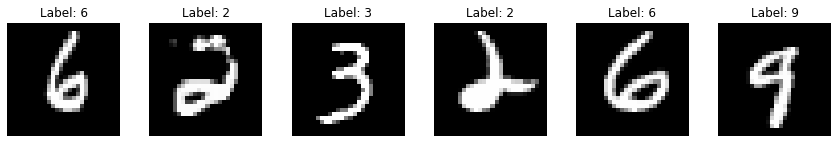

In [2]:
examples = iter(train_loader)
example_data, example_targets = next(examples)

print(f"Batch shape: {example_data.shape}")  # [batch_size, channels, height, width]
print(f"Target shape: {example_targets.shape}")  # [batch_size]

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(example_data[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {example_targets[i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Exercise 1: Define the Model

Implement a 3-layer MLP (Multi-Layer Perceptron) for MNIST classification. The architecture should be:

- **Input**: Flattened 28×28 image → 784 features
- **Hidden layer 1**: Linear(784, hidden_size) + ReLU
- **Hidden layer 2**: Linear(hidden_size, hidden_size) + ReLU
- **Output layer**: Linear(hidden_size, 10)

The `hidden_size` parameter controls model capacity — we will experiment with different values later.

In [ ]:
class Net(nn.Module):
    def __init__(
        self, input_size: int = 784, hidden_size: int = 1024, num_classes: int = 10
    ) -> None:
        super().__init__()
        # TODO: Define three linear layers and a ReLU activation
        raise NotImplementedError()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Flatten input, pass through layers with ReLU activations
        raise NotImplementedError()

### Training Utilities

The following helper functions are provided for training and evaluation. The `train_model` function:
1. Creates a `Net` with the specified `hidden_size`
2. Trains using Adam optimizer with cross-entropy loss
3. Tracks both **train** and **test** accuracy after each epoch
4. Returns the accuracy histories for plotting

In [ ]:
def evaluate(model: nn.Module, data_loader: DataLoader) -> float:
    """Compute accuracy on a dataset."""
    model.eval()
    correct: int = 0
    total: int = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def train_model(
    train_loader: DataLoader,
    test_loader: DataLoader,
    hidden_size: int = 1024,
    num_epochs: int = 10,
    weight_decay: float = 0.0,
) -> tuple[list[float], list[float], nn.Module]:
    """Train a Net and return (train_accuracies, test_accuracies, model)."""
    model: nn.Module = Net(hidden_size=hidden_size).to(device)
    criterion: nn.Module = nn.CrossEntropyLoss()
    optimizer: optim.Optimizer = optim.Adam(
        model.parameters(), lr=1e-3, weight_decay=weight_decay
    )

    train_accuracies: list[float] = []
    test_accuracies: list[float] = []

    for epoch in range(num_epochs):
        model.train()
        running_loss: float = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss: float = running_loss / len(train_loader)
        train_acc: float = evaluate(model, train_loader)
        test_acc: float = evaluate(model, test_loader)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}"
        )

    return train_accuracies, test_accuracies, model

### Exercise 2: Train on True Labels

Train the model on the original MNIST labels using `hidden_size=1024` and `num_epochs=5`. Store the results and plot the train/test accuracy curves.

**Task:**
1. Call `train_model` with the true-label data loaders
2. Plot train accuracy and test accuracy vs. epoch on the same axes
3. Observe: does the model generalize well?

In [ ]:
# Note: train_model now returns (train_accs, test_accs, model) — unpack accordingly
raise NotImplementedError()

### Exercise 3: Random Labels Experiment

This is the **key experiment** from the paper. We replace the true labels with **completely random labels** drawn uniformly from {0, 1, ..., 9}. Since the labels have no correlation with the images, a model that achieves high training accuracy is simply **memorizing** the dataset.

**Task:**
1. Implement the `RandomLabels` dataset wrapper below
2. Create data loaders with random labels (wrap the existing `train_dataset`)
3. Train the model for **25 epochs** (memorization takes longer than learning true patterns)
4. Observe: can the network memorize random labels? What happens to test accuracy?

In [ ]:
class RandomLabels(Dataset):
    """Wraps a dataset and replaces labels with random ones."""

    def __init__(self, base_dataset: Dataset, num_classes: int = 10, seed: int = 42) -> None:
        self.base: Dataset = base_dataset
        # TODO: Generate random labels for the entire dataset using the given seed
        # Use torch.Generator().manual_seed(seed) for reproducibility
        raise NotImplementedError()

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        # TODO: Return the original image with a random label
        raise NotImplementedError()

In [ ]:
# TODO: Wrap train_dataset and test_dataset with RandomLabels, create data loaders
# Then train for 25 epochs with hidden_size=1024
# Note: train_model returns (train_accs, test_accs, model) — unpack accordingly
raise NotImplementedError()

### Exercise 4: Comparison Plot

Create a side-by-side comparison of training on **true labels** vs. **random labels**.

**Task:**
1. Create a figure with 2 subplots
2. Left subplot: true labels — plot train accuracy, test accuracy, and generalization gap
3. Right subplot: random labels — plot train accuracy, test accuracy, and generalization gap
4. The **generalization gap** is defined as `train_accuracy - test_accuracy`

In [ ]:
# TODO: Create a side-by-side comparison plot
raise NotImplementedError()

### Exercise 5: Effect of Model Capacity

How does the size of the hidden layers affect the model's ability to fit and generalize?

**Task:**
1. Train models with `hidden_size` values `[50, 100, 200, 500, 1024]` on **true labels** for 10 epochs each
2. Record the **final** train and test accuracy for each hidden size
3. Plot final train accuracy and test accuracy vs. hidden size
4. Discuss: does a bigger model lead to worse generalization?

In [ ]:
# TODO: Train models with different hidden sizes and collect final accuracies
hidden_sizes = [50, 100, 200, 500, 1024]
raise NotImplementedError()

In [ ]:
# TODO: Plot final train and test accuracy vs. hidden size
raise NotImplementedError()

### Exercise 6: Weight Decay Regularization

The paper argues that explicit regularization (such as weight decay) is **neither necessary nor sufficient** for generalization. Let's test this claim empirically.

Weight decay (L2 regularization) adds a penalty term $\lambda \|\mathbf{w}\|^2$ to the loss, discouraging large weights. The `train_model` function already supports a `weight_decay` parameter that is passed to the Adam optimizer.

We already know from Exercise 2 that the unregularized model generalizes well on true labels. The more interesting question is: **can weight decay prevent the network from memorizing random labels?**

**Task:**
1. Train models with `weight_decay` values `[1e-3, 1e-2, 1e-1]` on **random labels** for 10 epochs each (`hidden_size=1024`)
2. Plot final train accuracy vs. weight decay
3. Discuss: does weight decay prevent memorization? What does this say about the paper's claim?

In [ ]:
# TODO: Train with different weight_decay values on random labels
weight_decays: list[float] = [1e-3, 1e-2, 1e-1]
raise NotImplementedError()

Compare our experimental setup and results with those reported in the paper. To what extent do our findings align with the original study? What similarities and discrepancies can be identified?

### Discussion Questions

**Q1:** In Exercise 6, you tested whether weight decay can prevent memorization or improve generalization. The paper's central claim is that explicit regularization is "neither necessary nor sufficient" for generalization. Based on your results, do you agree? If an unregularized model already generalizes well on true labels, what role (if any) does regularization actually play in deep learning?

**Q2:** The paper has over 6,000 citations, yet at its core it is based on a very simple experiment: training on random labels. Why do you think something so straightforward ended up having such a big impact on the field? What does this tell us about the value of empirical work vs. theoretical work in machine learning?